In [4]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 2.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [optuna]2m4/5 [optuna]

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
import optuna
from optuna.samplers import TPESampler
import warnings
ignore_warnings = warnings.filterwarnings("ignore")

df_tv = pd.read_csv("train_ind_prc.csv")
df_test = pd.read_csv("test_ind_prc.csv")
df_tv = df_tv.drop(['num__installment'], axis=1)
df_test = df_test.drop(['num__installment'], axis=1)


df_tv_exiti = df_tv.drop(['rf_rate','REAL_IRR'], axis=1)
df_test_exiti = df_test.drop(['rf_rate','REAL_IRR'], axis=1)

In [4]:
def cal_IRR(row):
    if row['pred_y'] == 1:
        return row['rf_rate']
    elif row['pred_y'] == 0:
        return row['REAL_IRR']
    else:
        return None

def cal_SR(df):
    excess_returns = df['IRR'] - df['rf_rate']
    if excess_returns.std() == 0:
        return 0
    return excess_returns.mean() / excess_returns.std()

In [5]:
# 최적 하이퍼파라미터를 찾기 위해 샘플 스플릿 with seed 0

X_tv = df_tv.drop('y', axis=1)
X_test = df_test.drop('y', axis=1)
y_tv = df_tv['y']
y_test = df_test['y']

X_train_R, X_val_R, y_train, y_val = train_test_split(X_tv, y_tv, stratify=y_tv, test_size=0.1, random_state=0)

X_train = X_train_R.drop(["rf_rate", "REAL_IRR"], axis=1) 
X_val = X_val_R.drop(["rf_rate", "REAL_IRR"], axis=1)

th = np.linspace(0.1, 0.9, 9)

def objective(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [(64,64), (64,64,32), (128,64)]),
        'activation': trial.suggest_categorical('activation', ['relu','tanh']),
        'solver': 'adam',
        'alpha': trial.suggest_loguniform('alpha', 1e-5, 1e-2),
        'learning_rate_init': trial.suggest_loguniform('learning_rate_init', 1e-4, 1e-2),
        'max_iter': 1000,
        'early_stopping': True   # 필요하면 False로 바꿔도 됨
    }
    model = MLPClassifier(**params)
    model.fit(X_train, y_train)  # <-- sample_weight 제거
    pred_proba = model.predict_proba(X_val)[:, 1]
    best_sr = -np.inf
    for threshold in th:
        pred_y = (pred_proba > threshold).astype(int)
        X_val_R_copy = X_val_R.copy()
        X_val_R_copy['pred_y'] = pred_y
        X_val_R_copy['IRR'] = X_val_R_copy.apply(cal_IRR, axis=1)
        sr = cal_SR(X_val_R_copy)
        if sr > best_sr:
            best_sr = sr

    return best_sr

study = optuna.create_study(
    direction='maximize',
    study_name='mlp_TPE',
    sampler=TPESampler(multivariate=True, group=True)
)
study.optimize(objective, n_trials=50)

[I 2025-08-21 12:46:25,754] A new study created in memory with name: mlp_TPE
[I 2025-08-21 12:47:10,861] Trial 0 finished with value: 0.18599809352407712 and parameters: {'hidden_layer_sizes': (64, 64, 32), 'activation': 'relu', 'alpha': 3.073531238242802e-05, 'learning_rate_init': 0.0001161440948516964}. Best is trial 0 with value: 0.18599809352407712.
[I 2025-08-21 12:47:45,988] Trial 1 finished with value: 0.18801044732041178 and parameters: {'hidden_layer_sizes': (64, 64, 32), 'activation': 'tanh', 'alpha': 2.2799001180082504e-05, 'learning_rate_init': 0.0009604965484917821}. Best is trial 1 with value: 0.18801044732041178.
[I 2025-08-21 12:48:23,890] Trial 2 finished with value: 0.18713540877002 and parameters: {'hidden_layer_sizes': (64, 64), 'activation': 'tanh', 'alpha': 0.0005031741779001541, 'learning_rate_init': 0.00010223731988540104}. Best is trial 1 with value: 0.18801044732041178.
[I 2025-08-21 12:48:51,271] Trial 3 finished with value: 0.14536272543085277 and parameters

In [6]:
optimal_params = {
    'hidden_layer_sizes': (64, 64),
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0003808345408079091,
    'learning_rate_init': 0.0009399693133569217,
    'max_iter': 5000,
    'early_stopping': True
}

Running bootstrap threshold optimization with fixed hyperparameters...

=== Bootstrap 1/30 ===
Bootstrap 1: Best Sharpe=0.1898, Threshold=0.165

=== Bootstrap 2/30 ===
Bootstrap 2: Best Sharpe=0.1879, Threshold=0.165

=== Bootstrap 3/30 ===
Bootstrap 3: Best Sharpe=0.1889, Threshold=0.165

=== Bootstrap 4/30 ===
Bootstrap 4: Best Sharpe=0.1893, Threshold=0.113

=== Bootstrap 5/30 ===
Bootstrap 5: Best Sharpe=0.1867, Threshold=0.165

=== Bootstrap 6/30 ===
Bootstrap 6: Best Sharpe=0.1940, Threshold=0.165

=== Bootstrap 7/30 ===
Bootstrap 7: Best Sharpe=0.1932, Threshold=0.165

=== Bootstrap 8/30 ===
Bootstrap 8: Best Sharpe=0.1885, Threshold=0.165

=== Bootstrap 9/30 ===
Bootstrap 9: Best Sharpe=0.1917, Threshold=0.165

=== Bootstrap 10/30 ===
Bootstrap 10: Best Sharpe=0.1894, Threshold=0.113

=== Bootstrap 11/30 ===
Bootstrap 11: Best Sharpe=0.1899, Threshold=0.165

=== Bootstrap 12/30 ===
Bootstrap 12: Best Sharpe=0.1891, Threshold=0.165

=== Bootstrap 13/30 ===
Bootstrap 13: Best Sha

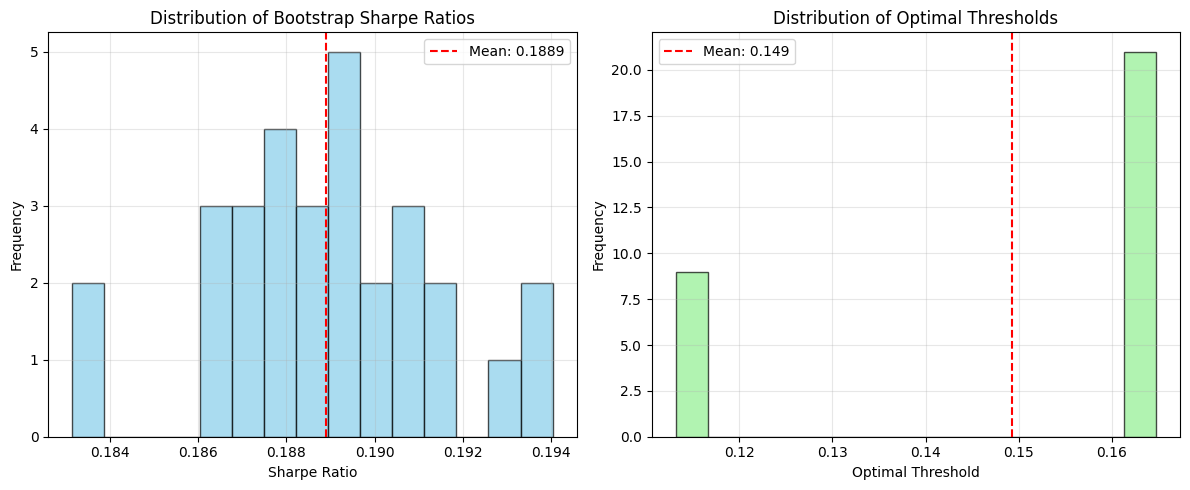

In [7]:
from sklearn.utils import resample

def bootstrap_threshold_optimization(df_tv, n_bootstrap, n_thresholds):
    best_results = []

    for i in range(n_bootstrap):
        print(f"\n=== Bootstrap {i+1}/{n_bootstrap} ===")
        
        # Bootstrap sampling
        df_boot = resample(df_tv, replace=True, n_samples=len(df_tv), random_state=i)
        X_tv = df_boot.drop('y', axis=1)
        y_tv = df_boot['y']
        X_test_R = df_test.drop('y', axis=1)

        X_train = X_tv.drop(["rf_rate", "REAL_IRR"], axis=1) 
        X_test = X_test_R.drop(["rf_rate", "REAL_IRR"], axis=1)

        # Train model with fixed optimal parameters

        model = MLPClassifier(**optimal_params)
        model.fit(X_train, y_tv)  # <-- sample_weight 제거
        pred_proba = model.predict_proba(X_test)[:, 1]

        thresholds = np.linspace(0.01, 0.99, n_thresholds)
        best_sr = -np.inf
        best_th = 0.5

        for threshold in thresholds:
            pred_y = (pred_proba > threshold).astype(int)
            X_test_copy = X_test_R.copy()
            X_test_copy['pred_y'] = pred_y
            X_test_copy['IRR'] = X_test_copy.apply(cal_IRR, axis=1)
            sr = cal_SR(X_test_copy)
            if sr > best_sr:
                best_sr = sr
                best_th = threshold
        best_results.append({
            'Bootstrap': i+1,
            'Sharpe': best_sr, 
            'threshold': best_th
        })
        print(f"Bootstrap {i+1}: Best Sharpe={best_sr:.4f}, Threshold={best_th:.3f}")
    return best_results

print("Running bootstrap threshold optimization with fixed hyperparameters...")
best_results = bootstrap_threshold_optimization(df_tv, n_bootstrap=30, n_thresholds=20)

# Display results
results_df = pd.DataFrame(best_results)
print("\n=== Final Results ===")
print(results_df[['Bootstrap', 'Sharpe', 'threshold']])
print(f"\nMean Sharpe: {results_df['Sharpe'].mean():.4f}")
print(f"Mean Threshold: {results_df['threshold'].mean():.4f}")
print(f"Std Sharpe: {results_df['Sharpe'].std():.4f}")
print(f"Best Sharpe: {results_df['Sharpe'].max():.4f}")

# Plot results
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of Sharpe ratios
ax1.hist(results_df['Sharpe'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(results_df['Sharpe'].mean(), color='red', linestyle='--', 
           label=f'Mean: {results_df["Sharpe"].mean():.4f}')
ax1.set_xlabel('Sharpe Ratio')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Bootstrap Sharpe Ratios')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of thresholds
ax2.hist(results_df['threshold'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.axvline(results_df['threshold'].mean(), color='red', linestyle='--',
           label=f'Mean: {results_df["threshold"].mean():.3f}')
ax2.set_xlabel('Optimal Threshold')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Optimal Thresholds')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()